In [1]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
  os.environ["GROQ_API_KEY"] =getpass.getpass("Enter the Groq API Key:")

Enter the Groq API Key:··········


In [2]:
! pip install langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.8 MB/s eta 0:00:00


In [3]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage,AIMessage

In [7]:
llm = ChatGroq(model ="openai/gpt-oss-120b",temperature=0,max_tokens=None,timeout=None,max_retries=3)

In [21]:
def product(a:int,b:int)->int:
   """Multiply a and b and return the result

   Args:
      a:First Integer
      b:Second Integer
   """
   return a *b

In [22]:
llm_with_tools= llm.bind_tools([product])

In [23]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is the product of 45 and 89?")])
tool_call

AIMessage(content='', additional_kwargs={'reasoning_content': "We need to compute 45*89 = 4005? Let's calculate: 45*80=3600, 45*9=405, sum=4005. So answer is 4005. Could also use function. Use function product.", 'tool_calls': [{'id': 'fc_bba374c8-7c4e-4145-9503-11310e29574a', 'function': {'arguments': '{"a":45,"b":89}', 'name': 'product'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 142, 'total_tokens': 228, 'completion_time': 0.179744971, 'completion_tokens_details': {'reasoning_tokens': 53}, 'prompt_time': 0.005616552, 'prompt_tokens_details': None, 'queue_time': 0.092832244, 'total_time': 0.185361523}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_f73454f048', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fc220-f221-7a81-b6eb-dce92d45f26b-0', tool_calls=[{'name': 'product', 'args': {'a': 45, 'b': 89}, 'id': 'fc_bba374c8-7c4e-4145-9503-11

In [24]:
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph,START,END

In [25]:
class MessagesState(MessagesState):
   pass

In [26]:
def tool_calling_llm(state:MessagesState):
   return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [27]:
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_edge(START,"tool_calling_llm")
builder.add_edge("tool_calling_llm",END)

In [28]:
graph =builder.compile()

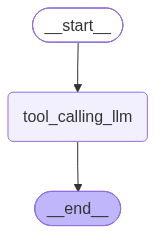

In [29]:
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
message = graph.invoke({"messages":HumanMessage(content="Give me some important news update today in tamilnadu?")})
for msg in message['messages']:
    msg.pretty_print()

================================ Human Message =================================

Give me some important news update today in tamilnadu?
================================== Ai Message ==================================

I’m sorry, but I don’t have access to real‑time information, so I can’t provide today’s news updates for Tamil Nadu.  

For the most current and reliable coverage, you might check any of the following sources:

| Type | Recommended Outlets (Tamil) |
|------|------------------------------|
| **State‑wide newspapers (online)** | **The Hindu – Tamil** (tamil.thehindu.com), **Dinamalar**, **Dinamani**, **Daily Thanthi**, **Makkal Kural** |
| **Television news portals** | **Sun News**, **Jaya TV News**, **NDTV Tamil**, **Zee Tamil News** (all have live streams and apps) |
| **News aggregators** | **Google News – Tamil**, **Inshorts (Tamil)**, **News18 Tamil** |
| **Social‑media handles (official)** | @TNGovt (Twitter), @CM_KKShivakumar (Twitter), @TNPolice (Twitter), and the 

In [32]:
message = graph.invoke({"messages":HumanMessage(content="Give me the product of 678956 and 15678")})
for msg in message['messages']:
    msg.pretty_print()

================================ Human Message =================================

Give me the product of 678956 and 15678
================================== Ai Message ==================================
Tool Calls:
  product (fc_03b4876f-73a3-4aab-892e-fd29e3f4b230)
 Call ID: fc_03b4876f-73a3-4aab-892e-fd29e3f4b230
  Args:
    a: 678956
    b: 15678
